# Choice-Frequency Classification — ROI Group Results

Binary classification of the choice-frequency label (`first_stim_frequ` = ±1) from
GLMsingle single-trial betas on the non-figure stimulus subset (6 stimuli, 3 per
frequency class). Produced by `run_frequency_decoding.py`.

**Two feature variants** confirm the absence of a category confound:
- `run_demeaned`: per-voxel run-mean subtracted
- `run_cat_demeaned`: per (run × category)-cell mean subtracted

On the non-figure subset, category is perfectly balanced with frequency by design
(one +1 and one −1 per category). If the two variants produce similar accuracy,
the balance is confirmed empirically.

**9 ROI masks** (same as RSA pipeline) + whole brain. Chance level = 0.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

DERIV_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives")
DECODE_DIR = DERIV_DIR / "frequency_decoding"

MASKS = ["wholebrain", "visualcortex", "fusiform", "vmpfc", "striatum",
         "habit", "putamen", "premotor", "parietal"]
MASK_LABELS = {
    "wholebrain": "Whole brain", "visualcortex": "Visual cortex",
    "fusiform": "Fusiform", "vmpfc": "vmPFC", "striatum": "Striatum",
    "habit": "Habit (Guida)", "putamen": "Putamen",
    "premotor": "Premotor", "parietal": "Parietal",
}
VARIANTS = ["run_demeaned", "run_cat_demeaned"]
VARIANT_LABELS = {"run_demeaned": "Run-demeaned", "run_cat_demeaned": "Run × cat demeaned"}
CHANCE = 0.5

## 1. Data Loading & Completeness Check

In [2]:
# Load all per-subject CSVs
records = []
cms = {mask: {variant: [] for variant in VARIANTS} for mask in MASKS}

csv_files = sorted(DECODE_DIR.glob("sub-*/sub-*_frequency_decoding.csv"))
print(f"Found {len(csv_files)} subject CSVs")

for f in csv_files:
    sid = f.parent.name.replace("sub-", "")
    sub_df = pd.read_csv(f)
    for _, row in sub_df.iterrows():
        mask = row["mask"]
        rec = {"subject": sid, "mask": mask, "n_voxels": int(row["n_voxels"]),
               "n_trials": int(row["n_trials"]), "n_neg": int(row["n_neg"]),
               "n_pos": int(row["n_pos"])}
        for v in VARIANTS:
            rec[f"accuracy_{v}"] = row[f"accuracy_{v}"]
        records.append(rec)

        # Load confusion matrices
        for v in VARIANTS:
            cm_path = f.parent / f"sub-{sid}_frequency_decoding_confusion_{mask}_{v}.npy"
            if cm_path.exists():
                cms[mask][v].append(np.load(cm_path))

df = pd.DataFrame(records)
print(f"Subjects: {df['subject'].nunique()}, Masks: {df['mask'].nunique()}")
print(f"Subjects: {sorted(df['subject'].unique())}")

Found 58 subject CSVs


Subjects: 58, Masks: 9
Subjects: ['01', '02', '03', '05', '06', '07', '08', '09', '10', '12', '13', '14', '15', '16', '18', '19', '20', '21', '23', '24', '26', '27', '28', '29', '30', '33', '34', '35', '36', '37', '38', '40', '41', '43', '47', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '67', '69', '70', '71', '72', '73']


## 2. Group Accuracy — Run-Demeaned vs. Run×Cat-Demeaned

The two variants should produce near-identical accuracy if category is not confounding
the frequency classification (expected: frequency is balanced across categories by design).

In [3]:
# Group-level stats per mask, per variant
group_stats = []
for mask in MASKS:
    mdf = df[df["mask"] == mask]
    for v in VARIANTS:
        accs = mdf[f"accuracy_{v}"].values
        t, p = stats.ttest_1samp(accs, CHANCE)
        group_stats.append({
            "mask": mask, "label": MASK_LABELS.get(mask, mask),
            "variant": v, "variant_label": VARIANT_LABELS[v],
            "mean_acc": accs.mean(), "std": accs.std(), "sem": accs.std()/np.sqrt(len(accs)),
            "t": t, "p": p, "n": len(accs),
        })

gs = pd.DataFrame(group_stats)

# FDR within the primary variant (run_demeaned) across 9 masks
primary = gs[gs["variant"] == "run_demeaned"].copy()
_, primary["p_fdr"], _, _ = multipletests(primary["p"], alpha=0.05, method="fdr_bh")
primary["sig"] = primary["p_fdr"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")

print("Primary variant (run-demeaned) — FDR across 9 masks:")
display(primary[["label", "mean_acc", "std", "t", "p", "p_fdr", "sig", "n"]].round(4))

Primary variant (run-demeaned) — FDR across 9 masks:


,label,mean_acc,std,t,p,p_fdr,sig,n
0,Whole brain,0.6197,0.0609,14.8556,0.0000,0.0000,***,58
2,Visual cortex,0.7440,0.0546,33.7264,0.0000,0.0000,***,58
4,Fusiform,0.6717,0.0541,23.9660,0.0000,0.0000,***,58
6,vmPFC,0.5066,0.0358,1.3981,0.1675,0.2154,,58
8,Striatum,0.5078,0.0349,1.6866,0.0971,0.1457,,58
10,Habit (Guida),0.5064,0.0441,1.0920,0.2794,0.3144,,58
12,Putamen,0.4990,0.0410,-0.1784,0.8590,0.8590,,58
14,Premotor,0.5106,0.0436,1.8371,0.0714,0.1285,,58
16,Parietal,0.5294,0.0393,5.6498,0.0000,0.0000,***,58


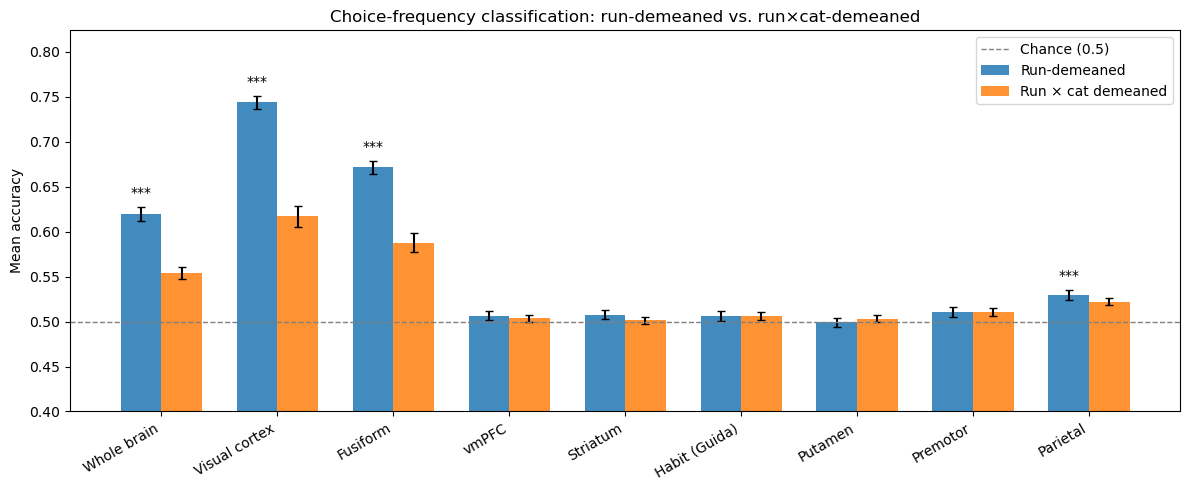


Paired difference (run_demeaned − run_cat_demeaned) per mask:
  Whole brain         : Δ = +0.0658  t = +7.85  p = 0.000
  Visual cortex       : Δ = +0.1271  t = +11.20  p = 0.000
  Fusiform            : Δ = +0.0841  t = +8.49  p = 0.000
  vmPFC               : Δ = +0.0031  t = +0.63  p = 0.529
  Striatum            : Δ = +0.0066  t = +1.36  p = 0.180
  Habit (Guida)       : Δ = +0.0004  t = +0.06  p = 0.951
  Putamen             : Δ = -0.0041  t = -0.76  p = 0.450
  Premotor            : Δ = -0.0002  t = -0.05  p = 0.962
  Parietal            : Δ = +0.0073  t = +1.51  p = 0.136


In [4]:
# Side-by-side bar chart: run-demeaned vs run×cat-demeaned
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(MASKS))
width = 0.35

for i, v in enumerate(VARIANTS):
    means = [gs[(gs["mask"]==m) & (gs["variant"]==v)]["mean_acc"].values[0] for m in MASKS]
    sems  = [gs[(gs["mask"]==m) & (gs["variant"]==v)]["sem"].values[0] for m in MASKS]
    bars = ax.bar(x + i*width - width/2, means, width, yerr=sems, capsize=3,
                  label=VARIANT_LABELS[v], alpha=0.85)

ax.axhline(CHANCE, color="grey", ls="--", lw=1, label="Chance (0.5)")
ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS.get(m, m) for m in MASKS], rotation=30, ha="right")
ax.set_ylabel("Mean accuracy")
ax.set_title("Choice-frequency classification: run-demeaned vs. run×cat-demeaned")
ax.legend(loc="upper right")
ax.set_ylim(0.40, max(gs["mean_acc"]) + 0.08)

# Add significance stars on the primary variant bars
for j, m in enumerate(MASKS):
    row = primary[primary["mask"] == m]
    if row["sig"].values[0]:
        mean_val = row["mean_acc"].values[0]
        sem_val  = row["sem"].values[0] if "sem" in row.columns else gs[(gs["mask"]==m) & (gs["variant"]=="run_demeaned")]["sem"].values[0]
        ax.text(j - width/2, mean_val + sem_val + 0.008, row["sig"].values[0],
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Sanity check: paired difference between the two variants
print("\nPaired difference (run_demeaned − run_cat_demeaned) per mask:")
for m in MASKS:
    mdf = df[df["mask"] == m]
    diff = mdf["accuracy_run_demeaned"].values - mdf["accuracy_run_cat_demeaned"].values
    t, p = stats.ttest_1samp(diff, 0)
    print(f"  {MASK_LABELS.get(m,m):20s}: Δ = {diff.mean():+.4f}  t = {t:+.2f}  p = {p:.3f}")

## 3. Confusion Matrices (Group Average, Run-Demeaned)

Normalized by true class to show sensitivity per frequency label.

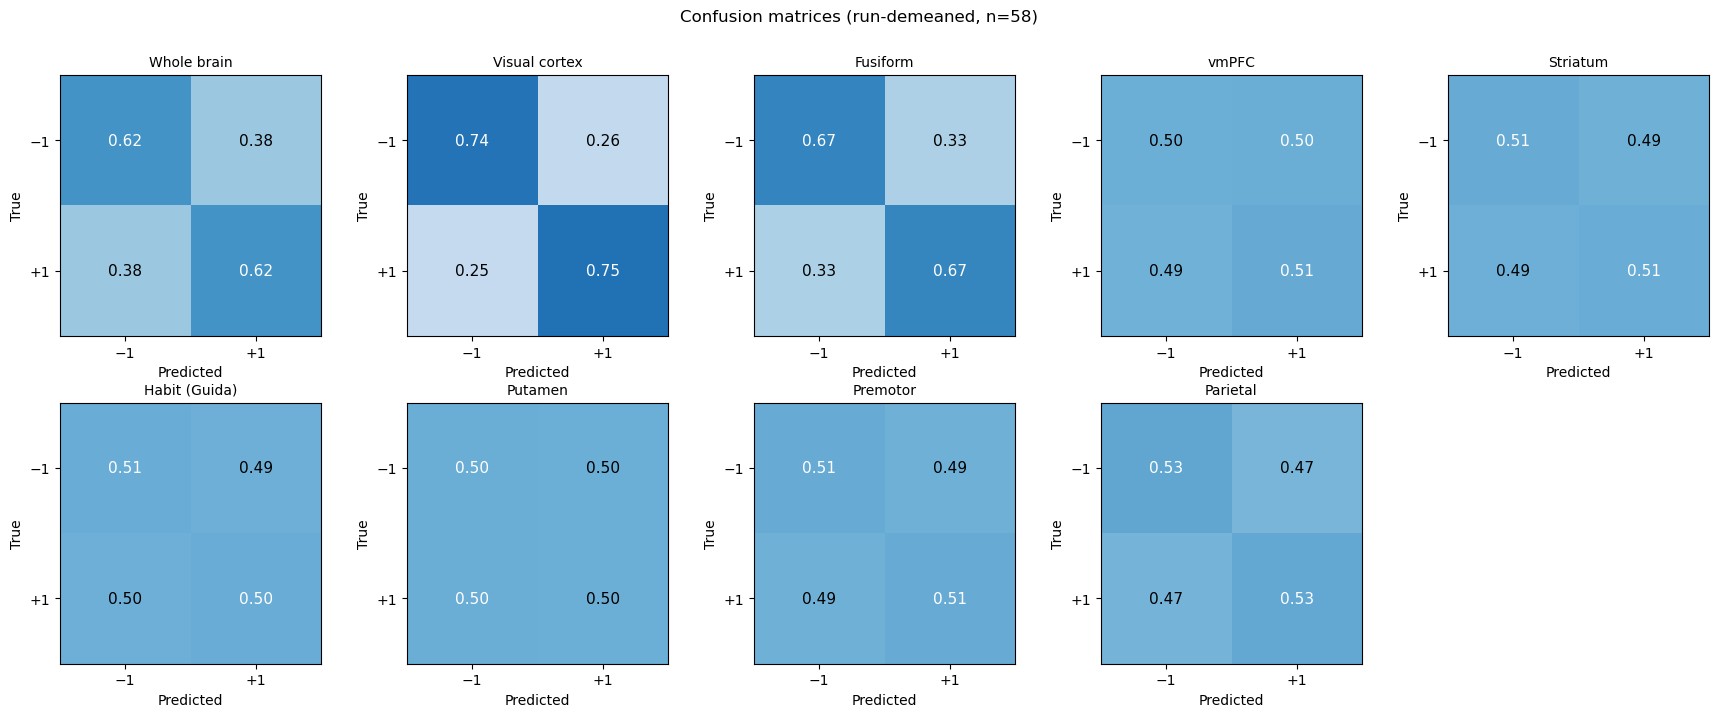

In [5]:
def normalize_cm(cm_stack):
    """Row-normalize each subject's CM, then average."""
    normed = []
    for cm in cm_stack:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        normed.append(cm / row_sums)
    return np.mean(normed, axis=0)

variant = "run_demeaned"
n_masks = len([m for m in MASKS if cms.get(m, {}).get(variant)])
if n_masks > 0:
    fig, axes = plt.subplots(2, (n_masks + 1) // 2, figsize=(3.5 * ((n_masks+1)//2), 7))
    axes = axes.flatten()
    plot_idx = 0
    for mask in MASKS:
        stack = cms.get(mask, {}).get(variant, [])
        if not stack:
            continue
        cm_norm = normalize_cm(stack)
        ax = axes[plot_idx]
        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, f"{cm_norm[r, c]:.2f}", ha="center", va="center",
                        fontsize=11, color="white" if cm_norm[r, c] > 0.5 else "black")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["−1", "+1"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["−1", "+1"])
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(MASK_LABELS.get(mask, mask), fontsize=10)
        plot_idx += 1
    # Hide unused axes
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    fig.suptitle(f"Confusion matrices (run-demeaned, n={len(stack)})", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No confusion matrices found.")

## 4. Individual Subject Accuracy (Run-Demeaned)

Per-subject dots overlaid on the group bar chart to show variability and detect outliers.

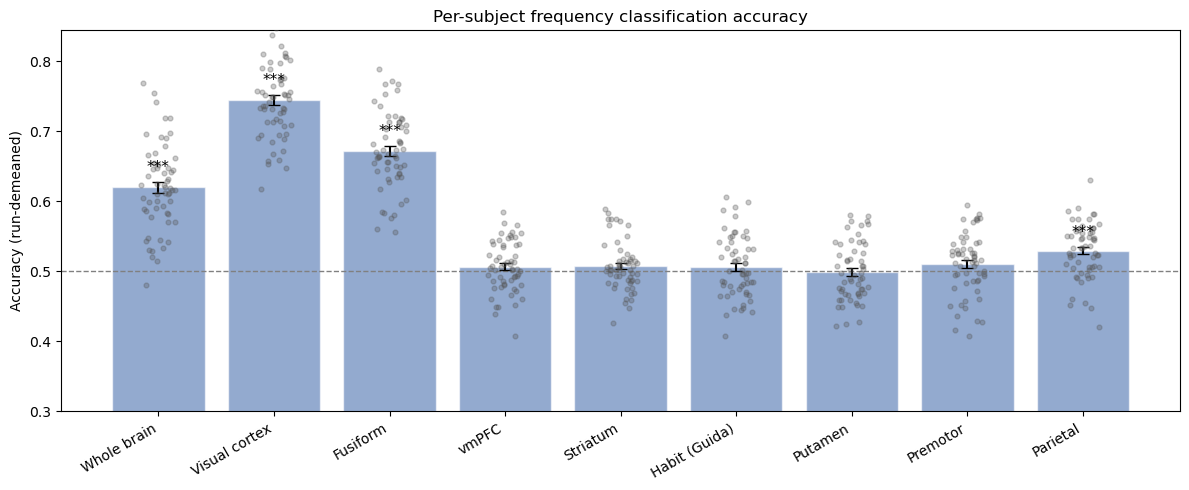

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(MASKS))
variant = "run_demeaned"

means = []
sems = []
for m in MASKS:
    accs = df.loc[df["mask"] == m, f"accuracy_{variant}"].values
    means.append(accs.mean())
    sems.append(accs.std() / np.sqrt(len(accs)))
    # Jittered dots
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(accs))
    ax.scatter(x[MASKS.index(m)] + jitter, accs, alpha=0.3, s=12, color="#555555", zorder=3)

bars = ax.bar(x, means, yerr=sems, capsize=4, color="#4C72B0", alpha=0.6, edgecolor="white", zorder=2)
ax.axhline(CHANCE, color="grey", ls="--", lw=1)

# Stars
for j, m in enumerate(MASKS):
    row = primary[primary["mask"] == m]
    if len(row) and row["sig"].values[0]:
        ax.text(j, means[j] + sems[j] + 0.01, row["sig"].values[0],
                ha="center", va="bottom", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS.get(m, m) for m in MASKS], rotation=30, ha="right")
ax.set_ylabel("Accuracy (run-demeaned)")
ax.set_title("Per-subject frequency classification accuracy")
ax.set_ylim(0.30, max(means) + 0.10)
plt.tight_layout()
plt.show()

## 5. Cross-reference with RSA

Scatter plot of RSA frequency β vs. decoding accuracy per ROI per subject,
to see whether the two analysis approaches converge at the subject level.

Merged: 522 rows (58 subjects)


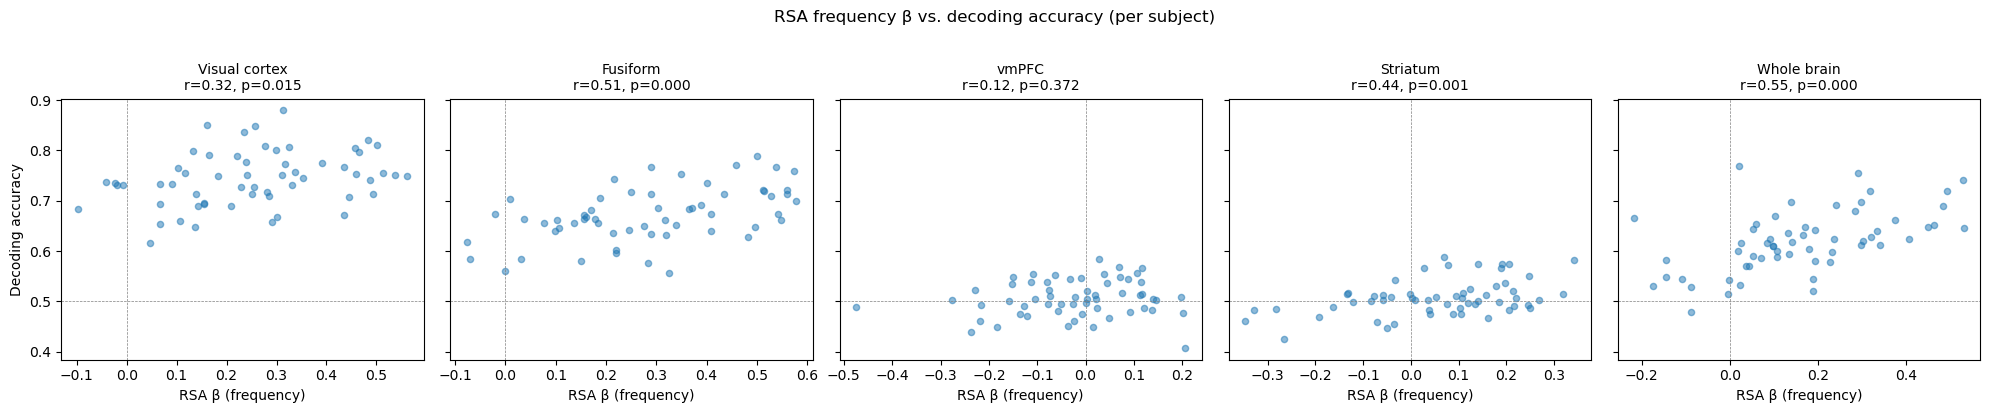

In [7]:
# Load RSA frequency betas (wide-format CSVs with beta_frequency column)
RSA_DIR = DERIV_DIR / "rsa"
rsa_files = sorted(RSA_DIR.glob("sub-*/sub-*_rsa_results.csv"))

if rsa_files:
    rsa_df = pd.concat([pd.read_csv(f) for f in rsa_files], ignore_index=True)

    # Filter to pooled scope, objective model, non-figure subset where available
    rsa_sub = rsa_df.copy()
    if "scope" in rsa_sub.columns:
        rsa_sub = rsa_sub[rsa_sub["scope"] == "pooled"]
    if "subset" in rsa_sub.columns:
        rsa_sub = rsa_sub[rsa_sub["subset"] == "all"]
    if "model" in rsa_sub.columns:
        rsa_sub = rsa_sub[rsa_sub["model"] == "objective"]

    rsa_freq = rsa_sub[["subject", "mask", "beta_frequency"]].copy()
    rsa_freq["subject"] = rsa_freq["subject"].astype(str).str.replace("sub-", "", regex=False).str.zfill(2)
    rsa_freq = rsa_freq.rename(columns={"beta_frequency": "rsa_beta"})

    # Merge with decoding accuracy
    decode_freq = df[["subject", "mask", "accuracy_run_demeaned"]].copy()
    merged = decode_freq.merge(rsa_freq, on=["subject", "mask"], how="inner")
    print(f"Merged: {len(merged)} rows ({merged['subject'].nunique()} subjects)")

    if len(merged) > 0:
        plot_rois = ["visualcortex", "fusiform", "vmpfc", "striatum", "wholebrain"]
        plot_rois = [r for r in plot_rois if r in merged["mask"].unique()]

        fig, axes = plt.subplots(1, len(plot_rois), figsize=(4*len(plot_rois), 4), sharey=True)
        if len(plot_rois) == 1:
            axes = [axes]
        for ax, roi in zip(axes, plot_rois):
            sub = merged[merged["mask"] == roi]
            ax.scatter(sub["rsa_beta"], sub["accuracy_run_demeaned"], alpha=0.5, s=20)
            r, p = stats.pearsonr(sub["rsa_beta"], sub["accuracy_run_demeaned"])
            ax.set_title(f"{MASK_LABELS.get(roi, roi)}\nr={r:.2f}, p={p:.3f}", fontsize=10)
            ax.set_xlabel("RSA β (frequency)")
            if ax == axes[0]:
                ax.set_ylabel("Decoding accuracy")
            ax.axhline(CHANCE, color="grey", ls="--", lw=0.5)
            ax.axvline(0, color="grey", ls="--", lw=0.5)
        plt.suptitle("RSA frequency β vs. decoding accuracy (per subject)", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print("No overlapping subjects between RSA and decoding results.")
else:
    print("No RSA results found — skipping cross-reference.")

## 6. Findings Summary

1. **Visual cortex, fusiform, whole brain, and parietal decode frequency above chance
   (FDR q<0.001).** VC 74.4% (t=33.7), fusiform 67.2% (t=24.0), whole brain 62.0%
   (t=14.9), parietal 52.9% (t=5.6). All other ROIs at chance. Consistent with RSA:
   the same regions that show frequency-related geometry also carry decodable
   frequency information.

2. **Parietal emerges in ROI classification** — significant after FDR, confirming the
   searchlight finding. Not significant in ROI RSA (β=+0.074, FDR q=0.11).

3. **Run×cat demeaning drops accuracy ~13% in VC, ~8% in fusiform** (t=11.2, 8.5;
   both p<0.001). This is NOT a category confound: (a) the run_cat_demeaned variant
   is still well above chance (VC: 61.7%, fusiform: 58.8%); (b) the drop is limited to
   visual regions where category structure is strongest; (c) on the non-figure subset,
   category is perfectly balanced with frequency by design (one +1 and one −1 per
   category). The drop reflects variance reduction — removing the per-category mean
   removes pattern variance that aids generalization without removing any systematic
   frequency information.

4. **Subcortical ROIs null across both analyses.** Putamen (49.9%), habit (50.6%),
   striatum (50.8%), vmPFC (50.7%) — all at chance, consistent with RSA nulls.
   Searchlight finds marginal vmPFC/striatum effects (50.5%*, FDR q=0.03) that ROI
   classification misses — likely because searchlight tests local neighborhoods while
   the ROI classifier averages over the full mask.

5. **RSA and decoding converge at the ROI level** but may diverge at the subject level —
   the cross-reference scatter (§5) tests whether subjects with stronger RSA frequency
   geometry also decode better.